In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
df=pd.read_csv('loan_approval_data.csv')
df.sample(10)

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
189,190.0,18646.0,3760.0,Contract,25.0,Single,1.0,695.0,4.0,0.40,NaN,11019.0,2934.0,84.0,NaN,Urban,Graduate,NaN,MNC,No
601,602.0,8881.0,281.0,NaN,49.0,Married,0.0,637.0,0.0,0.20,15522.0,38015.0,34405.0,12.0,Business,Rural,Graduate,NaN,Unemployed,No
864,865.0,2827.0,148.0,Self-employed,NaN,Single,1.0,596.0,0.0,NaN,5741.0,49713.0,2454.0,60.0,Business,Urban,Not Graduate,Male,Government,No
698,699.0,11795.0,7117.0,Salaried,22.0,Single,3.0,657.0,2.0,0.46,17529.0,1018.0,4536.0,12.0,Business,Rural,Graduate,Male,MNC,NaN
938,939.0,17534.0,3036.0,Contract,44.0,Married,1.0,737.0,4.0,0.26,18680.0,NaN,29152.0,48.0,Home,Urban,Graduate,Female,MNC,NaN
360,361.0,NaN,9078.0,Salaried,NaN,Married,2.0,662.0,2.0,0.42,8911.0,25989.0,12043.0,60.0,Education,Urban,Not Graduate,Female,MNC,No
503,504.0,NaN,7057.0,Unemployed,55.0,Married,0.0,600.0,NaN,0.19,3424.0,7210.0,23402.0,24.0,Personal,Rural,Not Graduate,Male,NaN,No
194,195.0,NaN,6467.0,Salaried,45.0,Married,0.0,764.0,0.0,0.16,8007.0,8744.0,21293.0,NaN,Home,NaN,Graduate,Male,Business,Yes
423,424.0,12518.0,8465.0,Contract,24.0,Married,3.0,642.0,NaN,0.18,1212.0,31921.0,8257.0,36.0,Car,Urban,Graduate,Female,Government,No
579,580.0,5419.0,NaN,Self-employed,33.0,Married,0.0,769.0,0.0,0.22,4261.0,5703.0,3994.0,24.0,Personal,Semiurban,Graduate,Male,Unemployed,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

<Axes: xlabel='Loan_Approved', ylabel='count'>

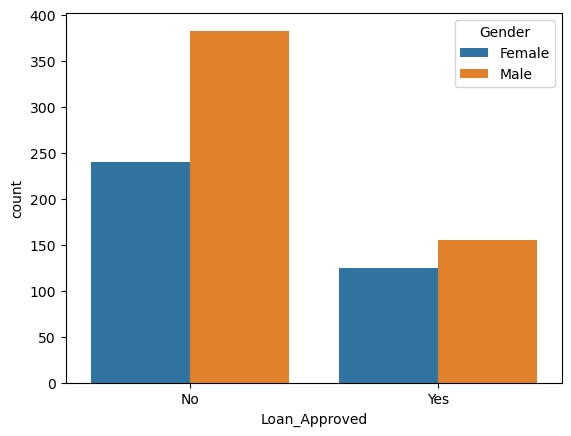

In [4]:
sns.countplot(
    data=df,
    x='Loan_Approved',
    hue='Gender'
)


In [5]:
df['Gender'].value_counts()

Gender
Male      571
Female    379
Name: count, dtype: int64

In [6]:
df.groupby('Gender')[['Applicant_Income','Credit_Score']].mean()


,Applicant_Income,Credit_Score
Gender,,
Female,10991.255556,679.776536
Male,10751.233333,672.972477


In [7]:
df.groupby('Gender')[['Loan_Purpose','Education_Level']].value_counts()

Gender  Loan_Purpose  Education_Level
Female  Business      Graduate           55
        Home          Graduate           55
        Education     Graduate           45
        Personal      Graduate           45
        Car           Graduate           44
        Education     Not Graduate       26
        Car           Not Graduate       23
        Business      Not Graduate       18
        Home          Not Graduate       18
        Personal      Not Graduate       16
Male    Business      Graduate           84
        Car           Graduate           84
        Personal      Graduate           71
        Education     Graduate           69
        Home          Graduate           62
        Car           Not Graduate       31
        Personal      Not Graduate       30
        Education     Not Graduate       29
        Home          Not Graduate       29
        Business      Not Graduate       24
Name: count, dtype: int64

In [8]:
df.groupby('Gender')['Loan_Purpose'].value_counts(normalize=True)


Gender  Loan_Purpose
Female  Home            0.216438
        Business        0.208219
        Education       0.205479
        Car             0.197260
        Personal        0.172603
Male    Car             0.220370
        Business        0.207407
        Education       0.194444
        Personal        0.194444
        Home            0.183333
Name: proportion, dtype: float64

In [9]:
df.groupby('Gender')['Loan_Amount'].mean()
df.groupby('Gender')['Savings'].mean()
df.groupby('Gender')['Age'].mean()

Gender
Female    39.259777
Male      40.440147
Name: Age, dtype: float64

In [10]:
df.groupby('Gender')['Marital_Status'].value_counts(normalize=True)

Gender  Marital_Status
Female  Married           0.629944
        Single            0.370056
Male    Married           0.623400
        Single            0.376600
Name: proportion, dtype: float64

In [11]:
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)

C:\Users\Yashika Sharma\AppData\Local\Temp\ipykernel_7796\3657246551.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)


<Axes: xlabel='Applicant_Income', ylabel='Loan_Amount'>

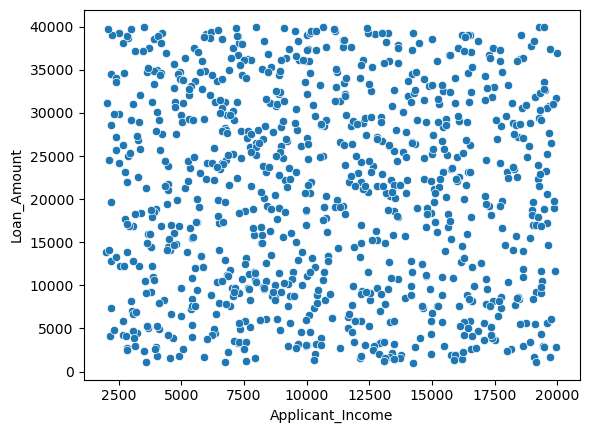

In [12]:
sns.scatterplot(
    data=df,
    x='Applicant_Income',
    y='Loan_Amount',
)

In [13]:
df[['Applicant_Income','Loan_Amount']].corr()

,Applicant_Income,Loan_Amount
Applicant_Income,1.000000,-0.025187
Loan_Amount,-0.025187,1.000000


In [14]:
df[['Loan_Amount','Credit_Score','DTI_Ratio','Collateral_Value','Savings']].corr()['Loan_Amount']

Loan_Amount         1.000000
Credit_Score        0.000957
DTI_Ratio           0.079525
Collateral_Value    0.002754
Savings            -0.012924
Name: Loan_Amount, dtype: float64

<Axes: xlabel='Loan_Purpose', ylabel='Loan_Amount'>

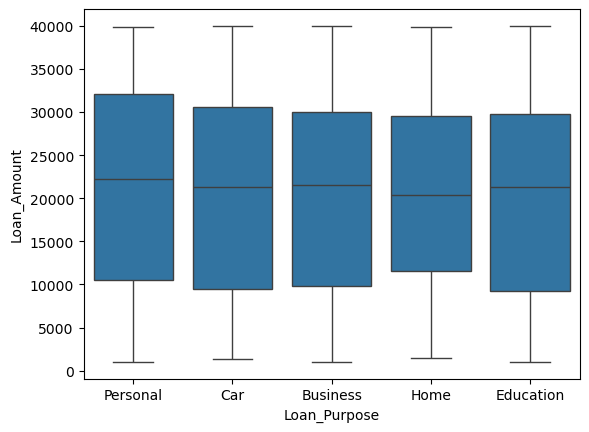

In [15]:
sns.boxplot(x='Loan_Purpose', y='Loan_Amount', data=df)

In [16]:
df.groupby('Loan_Purpose')['Loan_Amount'].mean()

Loan_Purpose
Business     20605.909574
Car          20364.645833
Education    20367.517647
Home         20499.723164
Personal     21318.885714
Name: Loan_Amount, dtype: float64

In [17]:
df.groupby(['Employment_Status','Education_Level','Employer_Category'])['Applicant_Income'].mean()

Employment_Status  Education_Level  Employer_Category
Contract           Graduate         Business              9939.650000
                                    Government           11042.153846
                                    MNC                  12862.250000
                                    Private              10353.482143
                                    Unemployed           12784.777778
                   Not Graduate     Business             10399.500000
                                    Government           11726.750000
                                    MNC                  11288.833333
                                    Private              10112.000000
                                    Unemployed            8925.666667
Salaried           Graduate         Business             11547.100000
                                    Government            9764.857143
                                    MNC                  13553.842105
                                    

In [18]:
group_median = df.groupby(
    ['Employment_Status', 'Employer_Category', 'Education_Level']
)['Applicant_Income'].median()


mask = df['Applicant_Income'].isnull()

df.loc[mask, 'Applicant_Income'] = df.loc[mask].set_index(
    ['Employment_Status', 'Employer_Category', 'Education_Level']
).index.map(group_median)


In [19]:
df['Applicant_Income'].isnull().sum()
df['Applicant_Income'].fillna(df['Applicant_Income'].median(), inplace=True)

C:\Users\Yashika Sharma\AppData\Local\Temp\ipykernel_7796\127274958.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Applicant_Income'].fillna(df['Applicant_Income'].median(), inplace=True)


In [20]:
df['Applicant_Income'].isnull().sum()

np.int64(0)

When I used groupby with transform to fill missing income, some values stayed or became NaN because of two reasons. First, if a row had a missing value in any of the columns used for grouping (like Employment Status, Employer Category, or Education Level), pandas excluded that row from the group, so when the new column was created, that row had no value and became NaN even if it had income before. Second, in some groups, all income values were already missing, so the median of that group was also NaN, and filling NaN with NaN did nothing. Because of these two cases, some values could not be filled and remained missing, which made it look like null values had increased.

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    1000 non-null   float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [22]:
df['Total_Income']=df['Coapplicant_Income']+df['Applicant_Income']

In [23]:
df.groupby('Loan_Approved')['Total_Income'].mean()

Loan_Approved
No     15513.000000
Yes    16946.059441
Name: Total_Income, dtype: float64

<Axes: xlabel='Loan_Approved', ylabel='Total_Income'>

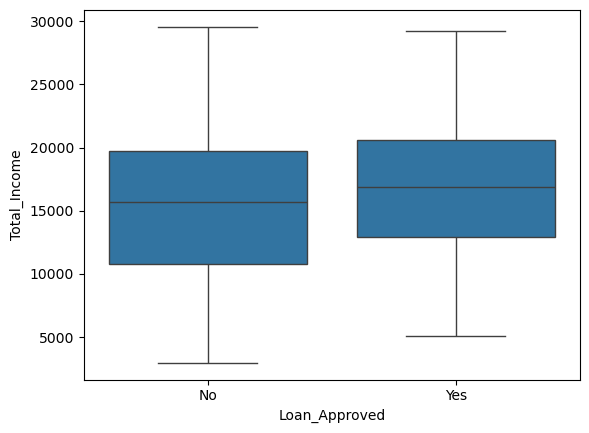

In [24]:
sns.boxplot(x='Loan_Approved', y='Total_Income', data=df)

In [25]:
df[df['Coapplicant_Income'].isnull()][['Marital_Status','Dependents']].head()

,Marital_Status,Dependents
8,Married,1.0
25,NaN,2.0
32,Single,2.0
89,Married,NaN
98,Married,1.0


In [26]:
df.groupby(['Dependents','Marital_Status'])[['Total_Income','Applicant_Income']].mean()

Total_Income  Applicant_Income
Dependents Marital_Status                                
0.0        Married         16711.859848      11215.082734
           Single          16070.941558      11032.969136
1.0        Married         16344.212230      11030.590000
           Single          15907.459596      10469.985577
2.0        Married         16221.336000      11103.082090
           Single          16535.412162      11769.740000
3.0        Married         15544.190299      10446.091241
           Single          15325.746753      10703.913580

In [27]:
df.groupby('Dependents')['Loan_Approved'].value_counts()

Dependents  Loan_Approved
0.0         No               145
            Yes               77
1.0         No               183
            Yes               75
2.0         No               138
            Yes               70
3.0         No               149
            Yes               66
Name: count, dtype: int64

In [28]:
df.groupby('Dependents')[['Applicant_Income','Total_Income']].mean()

,Applicant_Income,Total_Income
Dependents,,
0.0,11140.550000,16390.244292
1.0,10755.829630,16161.687747
2.0,11230.707763,16256.135922
3.0,10561.686147,15444.763393


In [29]:
df['Marital_Status'].fillna(df['Marital_Status'].mode()[0], inplace=True)


C:\Users\Yashika Sharma\AppData\Local\Temp\ipykernel_7796\1044597491.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Marital_Status'].fillna(df['Marital_Status'].mode()[0], inplace=True)


In [30]:
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)


C:\Users\Yashika Sharma\AppData\Local\Temp\ipykernel_7796\3517865738.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)


In [31]:
df['Coapplicant_Income'].fillna(df['Coapplicant_Income'].median(), inplace=True)


C:\Users\Yashika Sharma\AppData\Local\Temp\ipykernel_7796\4010783410.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Coapplicant_Income'].fillna(df['Coapplicant_Income'].median(), inplace=True)


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    1000 non-null   float64
 2   Coapplicant_Income  1000 non-null   float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      1000 non-null   object 
 6   Dependents          1000 non-null   float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [33]:
df.groupby(['Employer_Category','Employment_Status'])['Applicant_Income'].median()


Employer_Category  Employment_Status
Business           Contract              9043.50
                   Salaried             11608.00
                   Self-employed        11335.25
                   Unemployed            9390.00
Government         Contract             12457.00
                   Salaried             10006.50
                   Self-employed        11290.00
                   Unemployed           12230.50
MNC                Contract             12672.00
                   Salaried             13281.00
                   Self-employed        12271.50
                   Unemployed           10433.00
Private            Contract              9783.00
                   Salaried             10162.50
                   Self-employed        10172.00
                   Unemployed            9670.50
Unemployed         Contract             11865.00
                   Salaried              9875.00
                   Self-employed         9284.00
                   Unemployed   

In [34]:
df['Employer_Category'].fillna(
    df['Employer_Category'].mode()[0],
    inplace=True
)

C:\Users\Yashika Sharma\AppData\Local\Temp\ipykernel_7796\1832235500.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Employer_Category'].fillna(


In [35]:
status_map = df.groupby('Employer_Category')['Employment_Status'] \
             .agg(lambda x: x.mode()[0])



In [36]:
status_map

Employer_Category
Business      Salaried
Government    Salaried
MNC           Salaried
Private       Salaried
Unemployed    Salaried
Name: Employment_Status, dtype: object

In [37]:
mask = df['Employment_Status'].isnull()

df.loc[mask, 'Employment_Status'] = df.loc[mask, 'Employer_Category'].map(status_map)

# Safety fallback
df['Employment_Status'].fillna(df['Employment_Status'].mode()[0], inplace=True)


C:\Users\Yashika Sharma\AppData\Local\Temp\ipykernel_7796\317371801.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Employment_Status'].fillna(df['Employment_Status'].mode()[0], inplace=True)


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    1000 non-null   float64
 2   Coapplicant_Income  1000 non-null   float64
 3   Employment_Status   1000 non-null   object 
 4   Age                 950 non-null    float64
 5   Marital_Status      1000 non-null   object 
 6   Dependents          1000 non-null   float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

<Axes: xlabel='Loan_Approved', ylabel='Total_Income'>

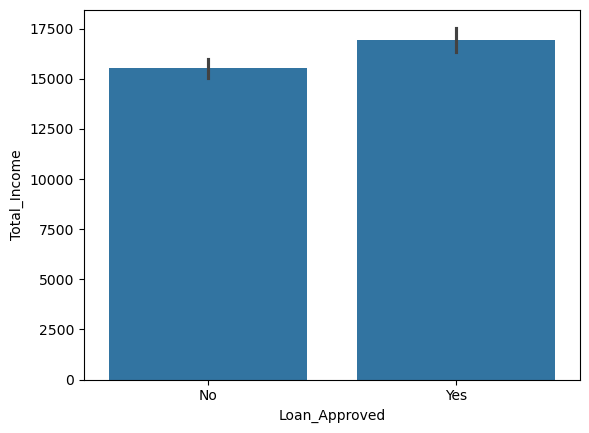

In [39]:
sns.barplot(
    data=df,
    y='Total_Income',
    x='Loan_Approved'
)

<Axes: xlabel='Loan_Approved', ylabel='Coapplicant_Income'>

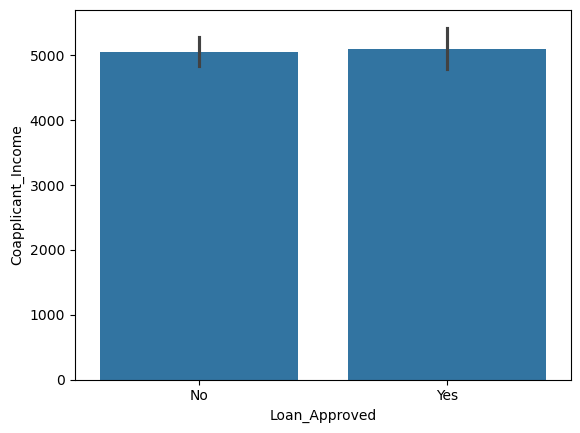

In [40]:
sns.barplot(
    data=df,
    y='Coapplicant_Income',
    x='Loan_Approved'
)

<Axes: xlabel='Age', ylabel='Count'>

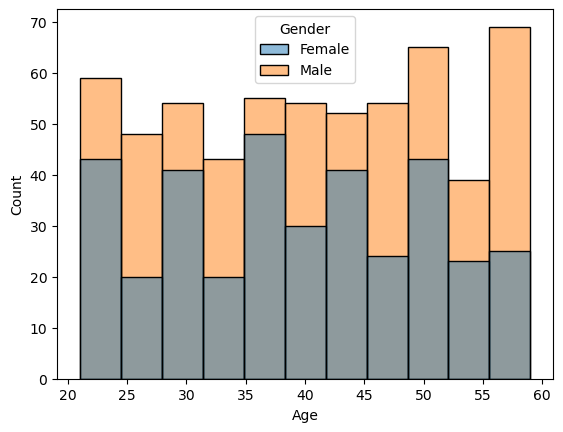

In [41]:
sns.histplot(
    data=df,
    x='Age',
    hue='Gender'
)

<Axes: xlabel='Age', ylabel='Credit_Score'>

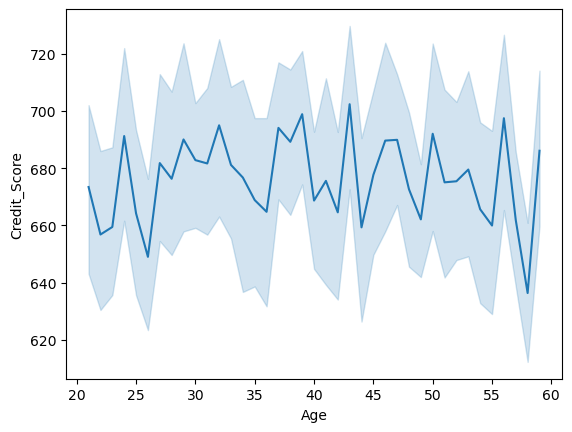

In [42]:
sns.lineplot(
    data=df,
    y='Credit_Score',
    x='Age'
)

<Axes: xlabel='Age', ylabel='Loan_Approved'>

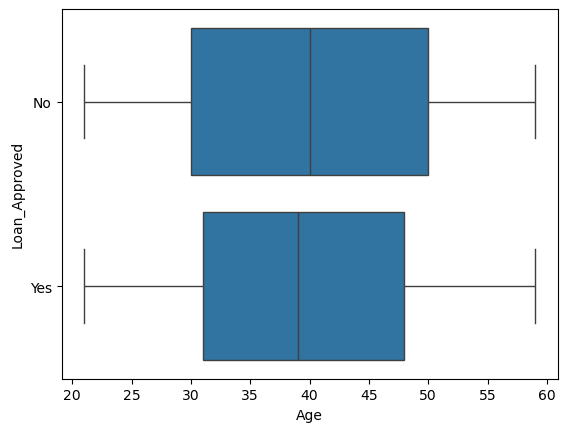

In [43]:
sns.boxplot(
    data=df,
    y='Loan_Approved',
    x='Age'
)

In [44]:
df.groupby('Loan_Approved')['Age'].mean()

Loan_Approved
No     40.257699
Yes    39.582456
Name: Age, dtype: float64

In [45]:
df['Age'].fillna(df['Age'].median(), inplace=True)

C:\Users\Yashika Sharma\AppData\Local\Temp\ipykernel_7796\1933487976.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    1000 non-null   float64
 2   Coapplicant_Income  1000 non-null   float64
 3   Employment_Status   1000 non-null   object 
 4   Age                 1000 non-null   float64
 5   Marital_Status      1000 non-null   object 
 6   Dependents          1000 non-null   float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [47]:
df.groupby('Existing_Loans')['Applicant_Income'].mean()

Existing_Loans
0.0    11295.997326
1.0    10785.786697
2.0    10731.472826
3.0    11063.423729
4.0    10899.600543
Name: Applicant_Income, dtype: float64

In [48]:
df.groupby('Existing_Loans')['Loan_Term'].mean()

Existing_Loans
0.0    45.559322
1.0    48.576923
2.0    45.053892
3.0    50.105263
4.0    50.915254
Name: Loan_Term, dtype: float64

<Axes: xlabel='Loan_Term', ylabel='Loan_Amount'>

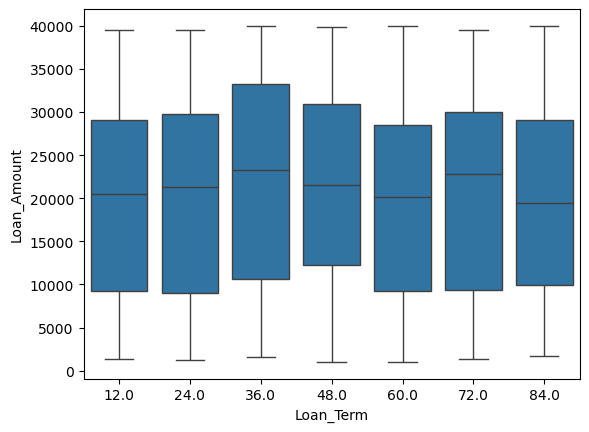

In [49]:
sns.boxplot(
    data=df,
    x='Loan_Term',
    y='Loan_Amount'
)

In [50]:
df.groupby('Loan_Term')['Loan_Amount'].mean()

Loan_Term
12.0    19612.851852
24.0    20429.139535
36.0    21898.745614
48.0    21174.765957
60.0    19640.185484
72.0    20840.639344
84.0    20010.313869
Name: Loan_Amount, dtype: float64

In [51]:
df.groupby('Loan_Purpose')['Loan_Amount'].mean()

Loan_Purpose
Business     20605.909574
Car          20364.645833
Education    20367.517647
Home         20499.723164
Personal     21318.885714
Name: Loan_Amount, dtype: float64

In [52]:
df.groupby('Loan_Purpose')['Dependents'].apply(pd.Series.mode)

Loan_Purpose   
Business      0    3.0
Car           0    1.0
Education     0    0.0
Home          0    1.0
Personal      0    1.0
Name: Dependents, dtype: float64

In [53]:
df['Loan_Purpose']=df['Loan_Purpose'].fillna(df['Loan_Purpose'].mode()[0])

In [54]:
loanAmount_map = df.groupby('Loan_Purpose')['Loan_Amount'].agg(lambda x: x.median())
mask = df['Loan_Amount'].isnull()

df.loc[mask, 'Loan_Amount'] = df.loc[mask, 'Loan_Purpose'].map(loanAmount_map)

# Safety fallback
#df['Loan_Amount'].fillna(df['Loan_Amount'].median(), inplace=True)

In [55]:
df['Loan_Amount'].isnull().sum()

np.int64(0)

In [56]:
df[['Loan_Term','Loan_Amount','Total_Income']].corr()

,Loan_Term,Loan_Amount,Total_Income
Loan_Term,1.000000,-0.000440,-0.023984
Loan_Amount,-0.000440,1.000000,-0.014126
Total_Income,-0.023984,-0.014126,1.000000


In [57]:
df.groupby('Loan_Purpose')['Loan_Term'].median()

Loan_Purpose
Business     48.0
Car          48.0
Education    48.0
Home         48.0
Personal     48.0
Name: Loan_Term, dtype: float64

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    1000 non-null   float64
 2   Coapplicant_Income  1000 non-null   float64
 3   Employment_Status   1000 non-null   object 
 4   Age                 1000 non-null   float64
 5   Marital_Status      1000 non-null   object 
 6   Dependents          1000 non-null   float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         1000 non-null   float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        1000 non-null   object 
 15  Property_Area       950 non-null    object 
 16  Educati

<Axes: xlabel='Total_Income', ylabel='Savings'>

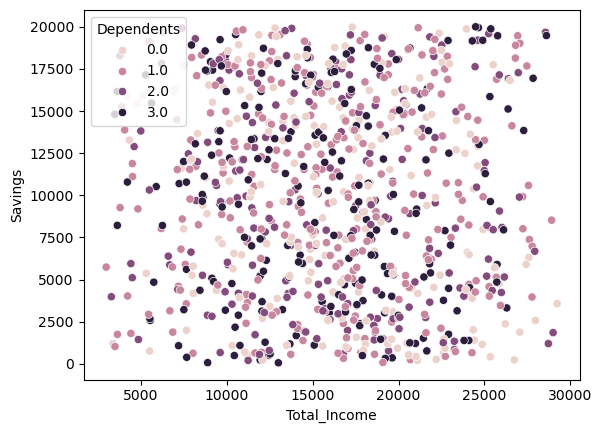

In [59]:
sns.scatterplot(
    data=df,
    x='Total_Income',
    y='Savings',
    hue='Dependents'
)

In [60]:
df.groupby('Dependents')[['Savings','Total_Income']].mean()

,Savings,Total_Income
Dependents,,
0.0,9774.990950,16390.244292
1.0,10266.867110,15938.689369
2.0,9817.771429,16256.135922
3.0,9775.678899,15444.763393


In [61]:
df[['Savings','Total_Income','Existing_Loans','DTI_Ratio','Dependents']].corr()

,Savings,Total_Income,Existing_Loans,DTI_Ratio,Dependents
Savings,1.000000,-0.036588,0.036499,0.004902,-0.010134
Total_Income,-0.036588,1.000000,-0.012249,0.022341,-0.046686
Existing_Loans,0.036499,-0.012249,1.000000,0.049748,-0.028899
DTI_Ratio,0.004902,0.022341,0.049748,1.000000,0.009053
Dependents,-0.010134,-0.046686,-0.028899,0.009053,1.000000


In [62]:
df['Savings'].fillna(df['Savings'].median(), inplace=True)


C:\Users\Yashika Sharma\AppData\Local\Temp\ipykernel_7796\462806946.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Savings'].fillna(df['Savings'].median(), inplace=True)


In [63]:
df['DTI_Ratio'].fillna(df['DTI_Ratio'].median(), inplace=True)


C:\Users\Yashika Sharma\AppData\Local\Temp\ipykernel_7796\3319641721.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['DTI_Ratio'].fillna(df['DTI_Ratio'].median(), inplace=True)


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    1000 non-null   float64
 2   Coapplicant_Income  1000 non-null   float64
 3   Employment_Status   1000 non-null   object 
 4   Age                 1000 non-null   float64
 5   Marital_Status      1000 non-null   object 
 6   Dependents          1000 non-null   float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           1000 non-null   float64
 10  Savings             1000 non-null   float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         1000 non-null   float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        1000 non-null   object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [65]:
df[['Existing_Loans','Loan_Term','Total_Income','Total_Income','Collateral_Value']].corr()

,Existing_Loans,Loan_Term,Total_Income,Total_Income,Collateral_Value
Existing_Loans,1.000000,0.069610,-0.012249,-0.012249,-0.052752
Loan_Term,0.069610,1.000000,-0.023984,-0.023984,0.041638
Total_Income,-0.012249,-0.023984,1.000000,1.000000,0.013021
Total_Income,-0.012249,-0.023984,1.000000,1.000000,0.013021
Collateral_Value,-0.052752,0.041638,0.013021,0.013021,1.000000


In [66]:
df['Collateral_Value'].fillna(df['Collateral_Value'].median(), inplace=True)

C:\Users\Yashika Sharma\AppData\Local\Temp\ipykernel_7796\2998711744.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Collateral_Value'].fillna(df['Collateral_Value'].median(), inplace=True)


In [67]:
df['Property_Area'].fillna(df['Property_Area'].mode()[0], inplace=True)

C:\Users\Yashika Sharma\AppData\Local\Temp\ipykernel_7796\240765716.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Property_Area'].fillna(df['Property_Area'].mode()[0], inplace=True)


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    1000 non-null   float64
 2   Coapplicant_Income  1000 non-null   float64
 3   Employment_Status   1000 non-null   object 
 4   Age                 1000 non-null   float64
 5   Marital_Status      1000 non-null   object 
 6   Dependents          1000 non-null   float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           1000 non-null   float64
 10  Savings             1000 non-null   float64
 11  Collateral_Value    1000 non-null   float64
 12  Loan_Amount         1000 non-null   float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        1000 non-null   object 
 15  Property_Area       1000 non-null   object 
 16  Educati

In [69]:
df.groupby('Employer_Category')['Education_Level'].apply(pd.Series.mode)

Employer_Category   
Business           0    Graduate
Government         0    Graduate
MNC                0    Graduate
Private            0    Graduate
Unemployed         0    Graduate
Name: Education_Level, dtype: object

In [70]:
df['Education_Level'].unique()

array(['Not Graduate', 'Graduate', nan], dtype=object)

In [71]:
df['Education_Level'].fillna(
    df['Education_Level'].mode()[0],
    inplace=True
)


C:\Users\Yashika Sharma\AppData\Local\Temp\ipykernel_7796\3263921824.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Education_Level'].fillna(


In [72]:
df['Existing_Loans'].fillna(df['Existing_Loans'].mode()[0], inplace=True)

C:\Users\Yashika Sharma\AppData\Local\Temp\ipykernel_7796\3879502444.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Existing_Loans'].fillna(df['Existing_Loans'].mode()[0], inplace=True)


In [73]:
df['Total_Income'] = df['Applicant_Income'] + df['Coapplicant_Income']


In [74]:
df.drop('Loan_Term', axis=1, inplace=True)
df.drop('Applicant_ID', axis=1, inplace=True)


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        950 non-null    float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Purpose        1000 non-null   object 
 13  Property_Area       1000 non-null   object 
 14  Education_Level     1000 non-null   object 
 15  Gender              1000 non-null   object 
 16  Employe

In [76]:
df[['Existing_Loans','Credit_Score','Total_Income','Loan_Amount','Age','DTI_Ratio']].corr()

,Existing_Loans,Credit_Score,Total_Income,Loan_Amount,Age,DTI_Ratio
Existing_Loans,1.000000,-0.004419,0.002406,-0.034373,0.030886,0.044291
Credit_Score,-0.004419,1.000000,0.023065,0.000863,-0.004335,0.002471
Total_Income,0.002406,0.023065,1.000000,-0.019320,-0.014254,0.023775
Loan_Amount,-0.034373,0.000863,-0.019320,1.000000,0.013302,0.075772
Age,0.030886,-0.004335,-0.014254,0.013302,1.000000,0.008149
DTI_Ratio,0.044291,0.002471,0.023775,0.075772,0.008149,1.000000


In [77]:
df.groupby('Loan_Approved')['Credit_Score'].mean()


Loan_Approved
No     651.559677
Yes    726.893617
Name: Credit_Score, dtype: float64

In [78]:
df['Credit_Score'].fillna(df['Credit_Score'].median(), inplace=True)

C:\Users\Yashika Sharma\AppData\Local\Temp\ipykernel_7796\2428711516.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Credit_Score'].fillna(df['Credit_Score'].median(), inplace=True)


In [79]:
df.sample(8)

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved,Total_Income
941,13485.0,2719.0,Contract,37.0,Single,0.0,708.0,3.0,0.37,9609.0,18185.0,25537.0,Business,Urban,Graduate,Male,Private,Yes,16204.0
747,11333.0,8636.0,Contract,27.0,Married,3.0,646.0,3.0,0.34,18057.0,19659.0,2753.0,Car,Rural,Not Graduate,Male,Business,No,19969.0
530,8042.0,9989.0,Salaried,37.0,Married,1.0,576.0,4.0,0.44,19541.0,19043.0,28066.0,Car,Urban,Graduate,Female,Private,No,18031.0
536,19308.0,2958.0,Salaried,42.0,Married,1.0,762.0,1.0,0.54,9880.5,41366.0,30283.0,Car,Urban,Not Graduate,Male,Private,No,22266.0
978,6425.0,5205.5,Unemployed,45.0,Single,0.0,669.0,0.0,0.42,9327.0,1137.0,23705.0,Personal,Semiurban,Not Graduate,Female,MNC,No,11630.5
996,3279.0,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,9880.5,18361.0,22563.0,Business,Urban,Graduate,Female,Government,No,9635.0
868,15635.0,9958.0,Salaried,37.0,Married,0.0,746.0,1.0,0.39,5704.0,10327.0,16775.0,Home,Urban,Graduate,Male,MNC,Yes,25593.0
637,19055.0,6812.0,Self-employed,49.0,Married,2.0,678.0,2.0,0.34,17140.0,48205.0,22182.0,Personal,Urban,Graduate,Male,MNC,Yes,25867.0


In [80]:
# 1. Remove rows with null target
# 2. Separate X and y
# 3. One-hot encode X
# 4. Train-test split
# 5. Scale
# 6. Train model


In [81]:
df_labeled = df[df['Loan_Approved'].notnull()].copy()

In [82]:
X = df_labeled.drop('Loan_Approved', axis=1)
y = df_labeled['Loan_Approved']


In [83]:
X = pd.get_dummies(X, drop_first=True, dtype='int')


In [84]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [85]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [86]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [87]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

          No       0.89      0.91      0.90       130
         Yes       0.79      0.75      0.77        60

    accuracy                           0.86       190
   macro avg       0.84      0.83      0.83       190
weighted avg       0.86      0.86      0.86       190



In [88]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


In [111]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])


In [112]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    pipe,
    X,
    y,
    cv=5,              # 5-fold CV
    scoring='accuracy'
)

print("CV scores:", scores)
print("Mean CV Accuracy:", scores.mean())


CV scores: [0.85263158 0.87894737 0.87894737 0.83684211 0.85263158]
Mean CV Accuracy: 0.86


In [91]:
# from sklearn.neighbors import KNeighborsClassifier

# pipe_knn = Pipeline([
#     ('scaler', StandardScaler()),
#     ('model', KNeighborsClassifier(n_neighbors=5))
# ])

# cross_val_score(pipe_knn, X, y, cv=5).mean()


In [92]:
# from sklearn.naive_bayes import GaussianNB

# cross_val_score(GaussianNB(), X, y, cv=5).mean()


In [113]:
param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 50],
    'model__penalty': ['l2'],
}


In [114]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring='f1_weighted',
    # n_jobs=-1   # use all cores
)

grid.fit(X, y)


,estimator,Pipeline(step..._iter=1000))])
,param_grid,"{'model__C': [0.01, 0.1, ...], 'model__penalty': ['l2']}"
,scoring,'f1_weighted'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [115]:
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)


Best Parameters: {'model__C': 0.1, 'model__penalty': 'l2'}
Best CV Score: 0.8554105291015663


In [99]:
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [100]:
param_knn = {
 'model__n_neighbors': [3, 5, 7, 9, 11, 15],
}
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])



In [102]:
grid_knn = GridSearchCV(
    pipe_knn,
    param_knn,
    cv=cv,
    scoring='f1_weighted'
)
grid_knn.fit(X, y)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'model__n_neighbors': [3, 5, ...]}"
,scoring,'f1_weighted'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [103]:
print("Best KNN Params:", grid_knn.best_params_)
print("Best KNN F1:", grid_knn.best_score_)


Best KNN Params: {'model__n_neighbors': 15}
Best KNN F1: 0.7641785706863039


In [104]:
from sklearn.naive_bayes import GaussianNB

In [109]:
param_nb = {
    'var_smoothing': [1e-12, 1e-10, 1e-9, 1e-8, 1e-7]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_nb = GridSearchCV(
    GaussianNB(),
    param_nb,
    cv=cv,
    scoring='f1_weighted',
)

grid_nb.fit(X, y)


,estimator,GaussianNB()
,param_grid,"{'var_smoothing': [1e-12, 1e-10, ...]}"
,scoring,'f1_weighted'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,priors,None


In [110]:
print("Best NB Params:", grid_nb.best_params_)
print("Best NB F1:", grid_nb.best_score_)

Best NB Params: {'var_smoothing': 1e-12}
Best NB F1: 0.8784858955439858
